# Predicting Depression from Social Media Use and Lifestyle Factors

## Overview

This project analyzes a dataset of 1,200 individuals to identify which behavioral and lifestyle factors are associated with depression, and to build a classification model that flags potentially depressed users from these factors.

**Dataset:** 1,200 rows, 13 columns. Mix of numeric (age, sleep hours, social media hours, stress, anxiety) and categorical (gender, platform usage, social interaction level) features. Target variable: binary depression label, with 31 (2.6%) positive cases.

## Key Findings

- Individuals labeled as depressed reported substantially less sleep (4.8 vs 6.5 hours, median), more daily social media use (7.0 vs 4.4 hours), higher stress (8 vs 5 on a 10-point scale), and higher anxiety (9 vs 6).
- A logistic regression model with class weighting and a tuned decision threshold (0.4) caught all 6 depressed users in the held-out test set, at the cost of 6 false positives among 234 non-depressed users.
- The four variables above account for the bulk of the model's predictive power. The model's coefficients on these features align with independent group-comparison evidence, suggesting it has learned real patterns rather than noise.
- No reliable relationship was found between depression and the remaining variables (age, screen time before sleep, academic performance, physical activity, addiction level, gender, or platform).

## Methods

1. Exploratory data analysis: distributions, correlations, group comparisons via boxplots.
2. Data preparation: one-hot encoding of categorical variables, stratified train/test split (80/20).
3. Model training: logistic regression (baseline), logistic regression with class weighting, Random Forest.
4. Model selection: chose threshold-tuned logistic regression based on use case (depression screening prioritizes recall).
5. Interpretation: feature coefficients cross-checked against EDA group differences to distinguish real signal from overfitting.

## Limitations

- Only 31 depressed cases (6 in the test set). Results on minority-class performance are noisy and not generalizable.
- The dataset appears clean and possibly synthetic. Real-world data would likely show messier relationships.
- No regularization or cross-validation was applied. Model coefficients on weak features (e.g., gender, platform) are likely overfit and not reported as findings.
- This is a correlational analysis. No causal claims can be made about whether social media use, sleep, or stress *cause* depression versus being associated with it.

## 1. Setup and Data Loading

Loading the required libraries and the dataset.

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [153]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/algozee/teenager-menthal-healy/Teen_Mental_Health_Dataset.csv


In [154]:
df = pd.read_csv('data/Teen_Mental_Health_Dataset.csv')

## 2. Initial Data Inspection

Checking the basic structure of the dataset: shape, column types, missing values, and summary statistics for both numeric and categorical features.

In [155]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [156]:
df.shape

(1200, 13)

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [158]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [159]:
df.describe(include='object')

,gender,platform_usage,social_interaction_level
count,1200,1200,1200
unique,2,3,3
top,male,Instagram,medium
freq,615,411,416


In [160]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [161]:
df['platform_usage'].value_counts()

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

## 3. Exploratory Data Analysis

Visualizing distributions and relationships between variables. The goal is to understand the data's structure and identify which features might predict depression before building any models.

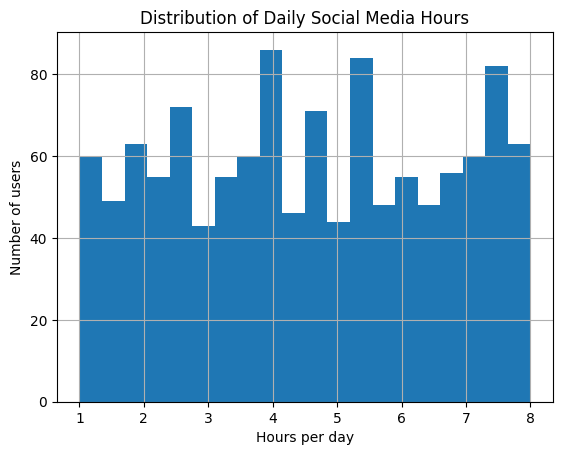

In [162]:
df['daily_social_media_hours'].hist(bins=20)
plt.title('Distribution of Daily Social Media Hours')
plt.xlabel('Hours per day')
plt.ylabel('Number of users')
plt.show()

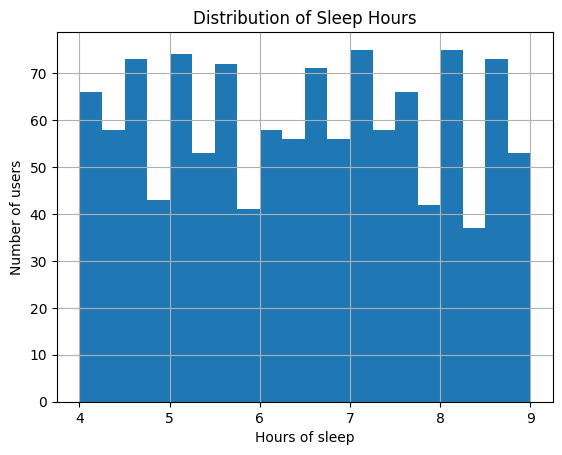

In [167]:
df['sleep_hours'].hist(bins=20)
plt.title('Distribution of Sleep Hours')
plt.xlabel('Hours of sleep')
plt.ylabel('Number of users')
plt.show()

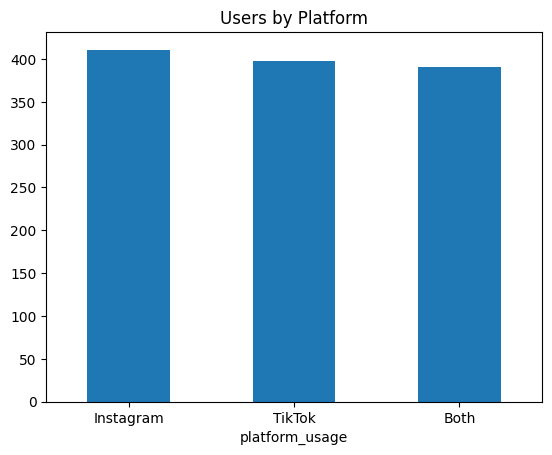

In [168]:
df['platform_usage'].value_counts().plot(kind='bar')
plt.title('Users by Platform')
plt.xticks(rotation=0)
plt.show()

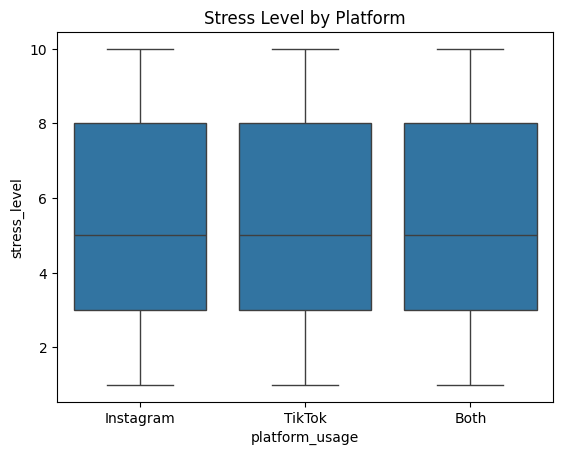

In [169]:
sns.boxplot(data=df, x='platform_usage', y='stress_level')
plt.title('Stress Level by Platform')
plt.show()

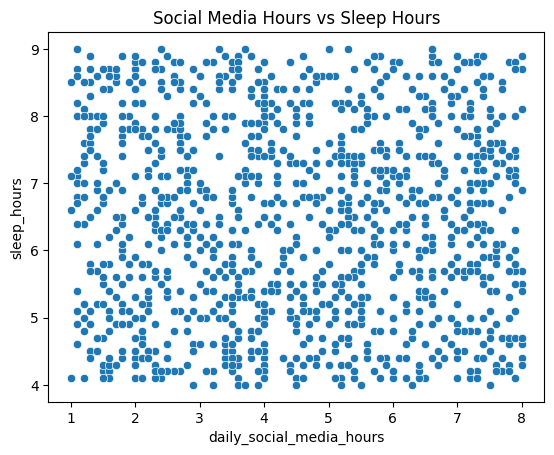

In [170]:
sns.scatterplot(data=df, x='daily_social_media_hours', y='sleep_hours')
plt.title('Social Media Hours vs Sleep Hours')
plt.show()

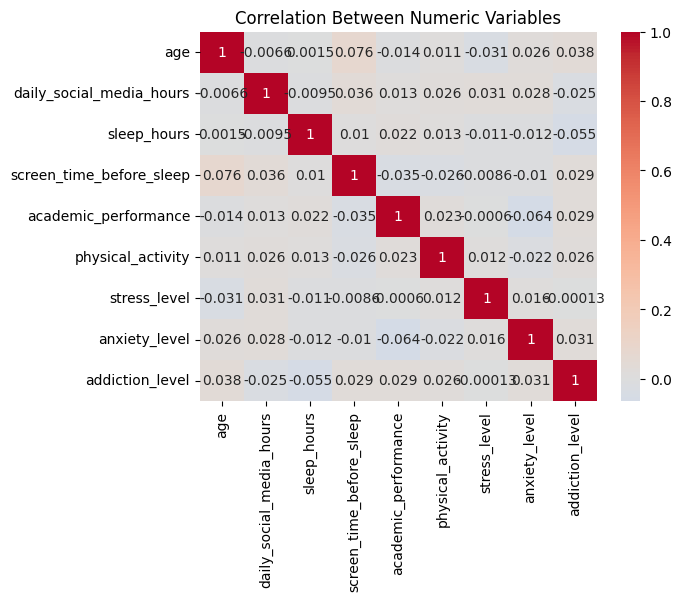

In [171]:
numeric_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                'academic_performance', 'physical_activity', 'stress_level',
                'anxiety_level', 'addiction_level']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Variables')
plt.show()

In [172]:
df['depression_label'].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

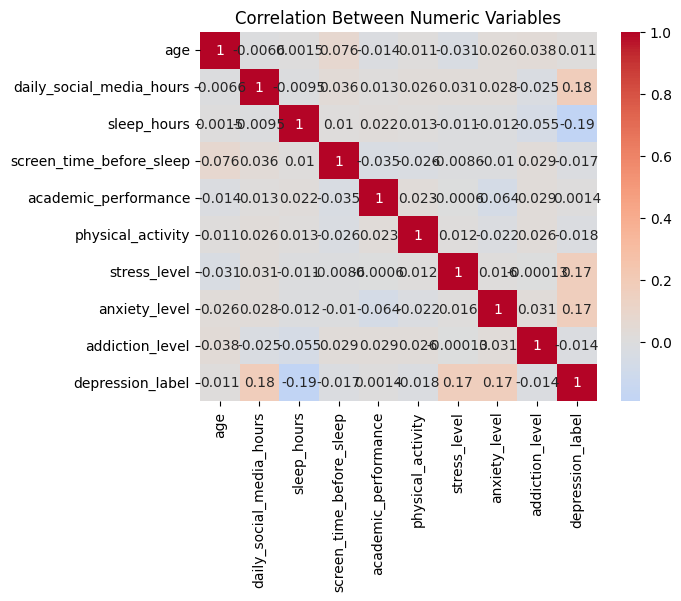

In [174]:
numeric_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                'academic_performance', 'physical_activity', 'stress_level',
                'anxiety_level', 'addiction_level', 'depression_label']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Variables')
plt.show()

In [175]:
df.groupby('depression_label').mean(numeric_only=True)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level
depression_label,,,,,,,,,
0,15.924722,4.478785,6.494183,1.742258,2.990248,1.016168,5.365269,5.557742,5.571429
1,16.064516,6.719355,4.761290,1.667742,2.995484,0.951613,8.483871,8.612903,5.322581


## 4. Group Comparison: Depressed vs Non-Depressed

Comparing the two groups on each key variable to identify which features show meaningful differences. These comparisons form the independent evidence used later to validate the model's findings.

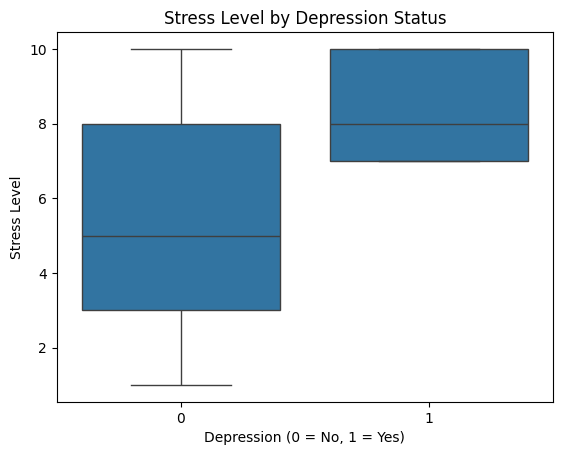

In [177]:
sns.boxplot(data=df, x='depression_label', y='stress_level')
plt.title('Stress Level by Depression Status')
plt.xlabel('Depression (0 = No, 1 = Yes)')
plt.ylabel('Stress Level')
plt.show()

In [178]:
df.groupby('depression_label')['stress_level'].median()

depression_label
0    5.0
1    8.0
Name: stress_level, dtype: float64

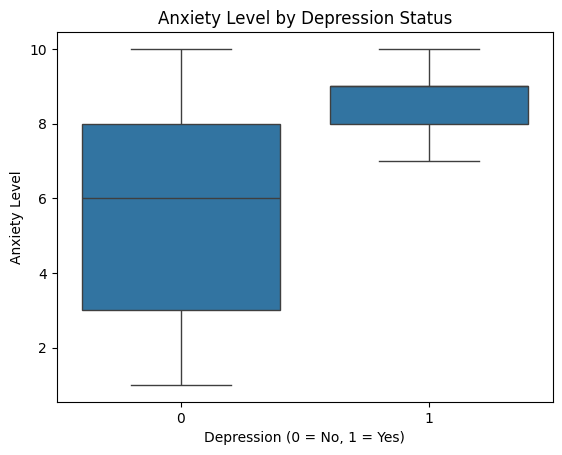

In [179]:
sns.boxplot(data=df, x='depression_label', y='anxiety_level')
plt.title('Anxiety Level by Depression Status')
plt.xlabel('Depression (0 = No, 1 = Yes)')
plt.ylabel('Anxiety Level')
plt.show()

In [180]:
df.groupby('depression_label')['anxiety_level'].median()

depression_label
0    6.0
1    9.0
Name: anxiety_level, dtype: float64

## 5. Data Preparation for Modeling

Separating features from target, one-hot encoding categorical variables, and splitting the data into training and test sets with stratification to preserve the class imbalance ratio.

In [192]:
X = df.drop('depression_label', axis=1)
y = df['depression_label']

In [193]:
print(X.shape)
print(y.shape)

(1200, 12)
(1200,)


In [194]:
X.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level'],
      dtype='object')

In [195]:
X = pd.get_dummies(X, columns=['gender', 'platform_usage', 'social_interaction_level'], drop_first=True)

In [196]:
print(X.shape)
print(X.columns)

(1200, 14)
Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'gender_male',
       'platform_usage_Instagram', 'platform_usage_TikTok',
       'social_interaction_level_low', 'social_interaction_level_medium'],
      dtype='object')


In [198]:
X = X * 1

In [199]:
X.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,1


In [200]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [201]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train depression rate:", y_train.mean())
print("y_test depression rate:", y_test.mean())

X_train: (960, 14)
X_test: (240, 14)
y_train depression rate: 0.026041666666666668
y_test depression rate: 0.025


## 6. Model Training and Evaluation

Training three models — a baseline logistic regression, a class-weighted version, and a Random Forest — and comparing them on imbalanced-data-appropriate metrics (precision, recall, F1) rather than accuracy.

In [202]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [203]:
predictions = model.predict(X_test)
print(predictions[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [204]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9875


In [205]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print(cm)

[[234   0]
 [  3   3]]


In [206]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240



In [207]:
model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

predictions_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, predictions_balanced))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       234
           1       0.56      0.83      0.67         6

    accuracy                           0.98       240
   macro avg       0.78      0.91      0.83       240
weighted avg       0.98      0.98      0.98       240



In [209]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240



## 7. Threshold Tuning

The class-weighted logistic regression caught 5 of 6 depressed cases. Examining the model's predicted probabilities to determine if a lower decision threshold could catch the missed case without too many false alarms.

In [210]:
probabilities = model_balanced.predict_proba(X_test)
print(probabilities[:10])

[[9.99566298e-01 4.33702338e-04]
 [9.41869745e-01 5.81302546e-02]
 [9.99999999e-01 1.35716735e-09]
 [9.99971622e-01 2.83779477e-05]
 [9.99811947e-01 1.88052776e-04]
 [9.99988803e-01 1.11970839e-05]
 [9.99768280e-01 2.31720267e-04]
 [9.99999996e-01 3.88736528e-09]
 [9.99999861e-01 1.39289608e-07]
 [9.99952111e-01 4.78889157e-05]]


In [211]:
probs_class_1 = probabilities[:, 1]

import numpy as np
depressed_mask = (y_test.values == 1)
print("Probabilities for the 6 truly depressed people:")
print(np.sort(probs_class_1[depressed_mask]))

Probabilities for the 6 truly depressed people:
[0.41270512 0.69275704 0.96427012 0.97602706 0.98494564 0.99922627]


In [212]:
non_depressed_probs = probs_class_1[~depressed_mask]

print(f"Total non-depressed in test set: {len(non_depressed_probs)}")
print(f"Non-depressed with probability >= 0.5: {(non_depressed_probs >= 0.5).sum()}")
print(f"Non-depressed with probability >= 0.4: {(non_depressed_probs >= 0.4).sum()}")
print(f"Non-depressed with probability >= 0.3: {(non_depressed_probs >= 0.3).sum()}")
print(f"Non-depressed with probability >= 0.2: {(non_depressed_probs >= 0.2).sum()}")

Total non-depressed in test set: 234
Non-depressed with probability >= 0.5: 4
Non-depressed with probability >= 0.4: 6
Non-depressed with probability >= 0.3: 10
Non-depressed with probability >= 0.2: 14


In [213]:
threshold = 0.4
predictions_tuned = (probs_class_1 >= threshold).astype(int)

print(classification_report(y_test, predictions_tuned))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       234
           1       0.50      1.00      0.67         6

    accuracy                           0.97       240
   macro avg       0.75      0.99      0.83       240
weighted avg       0.99      0.97      0.98       240



## 8. Model Interpretation

Examining which features the model relies on most, and cross-checking those findings against the group differences identified in EDA. Features where the model's coefficient is large but EDA shows no group difference are flagged as likely overfitting artifacts.

In [214]:
import pandas as pd

coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model_balanced.coef_[0]
})

coefficients['abs_coefficient'] = coefficients['coefficient'].abs()
coefficients = coefficients.sort_values('abs_coefficient', ascending=False)

print(coefficients[['feature', 'coefficient']])

                            feature  coefficient
2                       sleep_hours    -2.643434
9                       gender_male    -1.810767
10         platform_usage_Instagram    -1.487718
7                     anxiety_level     1.258422
1          daily_social_media_hours     1.221654
13  social_interaction_level_medium     1.073484
6                      stress_level     1.052427
4              academic_performance     1.035350
11            platform_usage_TikTok    -0.286286
8                   addiction_level     0.249781
12     social_interaction_level_low    -0.189829
0                               age    -0.149403
3          screen_time_before_sleep    -0.089528
5                 physical_activity     0.010378


In [215]:
print(df.groupby('depression_label')['gender'].value_counts())
print()
print(df.groupby('depression_label')['platform_usage'].value_counts())

depression_label  gender
0                 male      601
                  female    568
1                 female     17
                  male       14
Name: count, dtype: int64

depression_label  platform_usage
0                 Instagram         401
                  TikTok            386
                  Both              382
1                 TikTok             12
                  Instagram          10
                  Both                9
Name: count, dtype: int64


## 9. Visualizations

Three visualizations summarizing the analysis: model coefficients, confusion matrix at the chosen threshold, and a comparison of model coefficients against independent EDA evidence for each numeric feature.

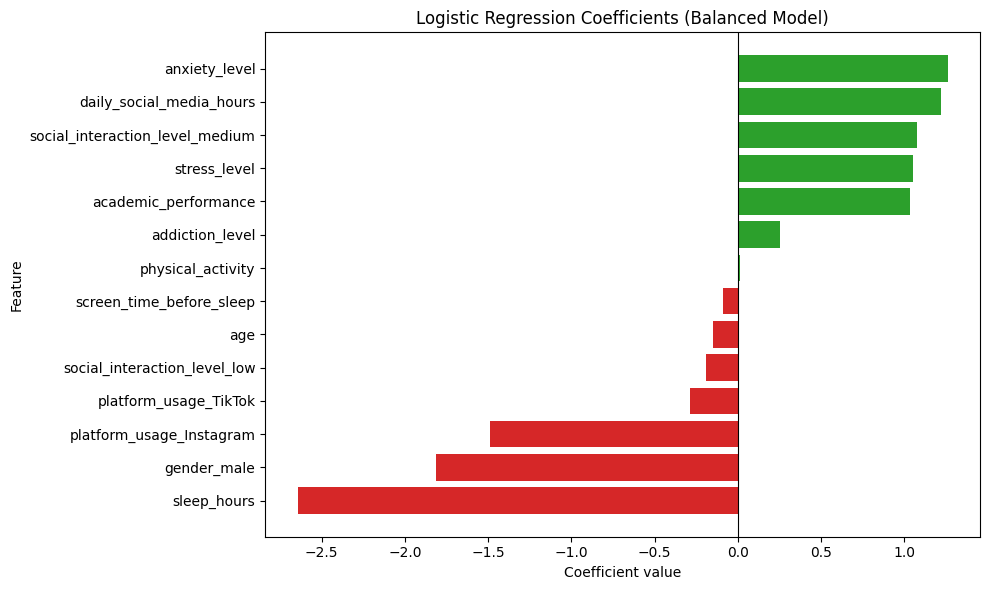

In [217]:
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient')

colors = ['#d62728' if c < 0 else '#2ca02c' for c in coef_df['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (Balanced Model)')
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

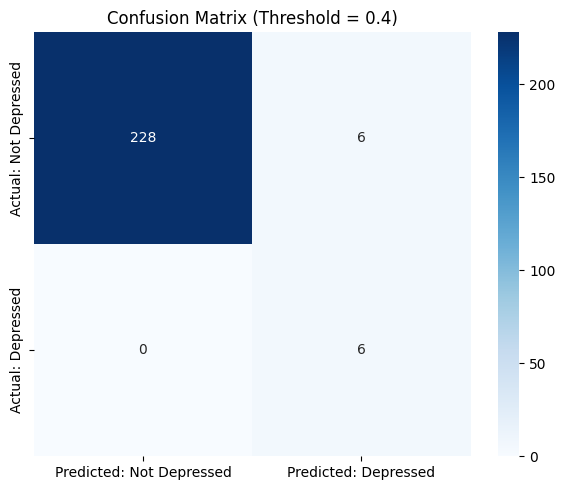

In [218]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Not Depressed', 'Predicted: Depressed'],
            yticklabels=['Actual: Not Depressed', 'Actual: Depressed'])
plt.title('Confusion Matrix (Threshold = 0.4)')
plt.tight_layout()
plt.show()

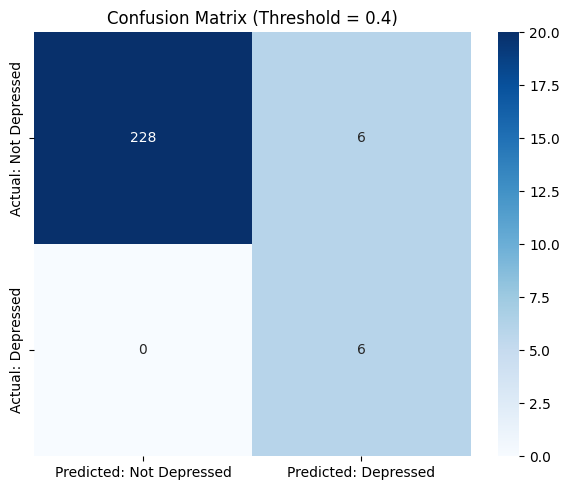

In [219]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', vmax=20,
            xticklabels=['Predicted: Not Depressed', 'Predicted: Depressed'],
            yticklabels=['Actual: Not Depressed', 'Actual: Depressed'])
plt.title('Confusion Matrix (Threshold = 0.4)')
plt.tight_layout()
plt.show()

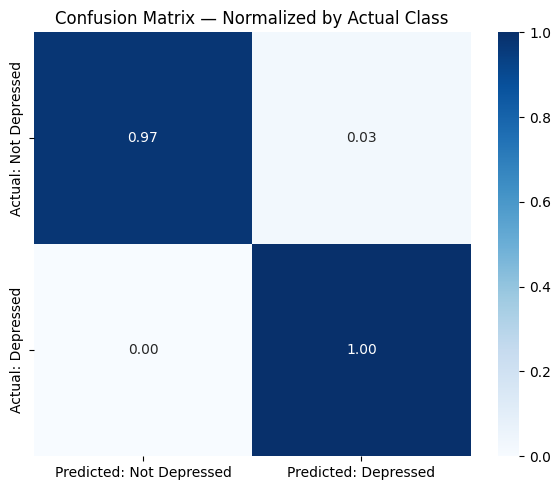

In [220]:
cm_normalized = confusion_matrix(y_test, predictions_tuned, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Predicted: Not Depressed', 'Predicted: Depressed'],
            yticklabels=['Actual: Not Depressed', 'Actual: Depressed'])
plt.title('Confusion Matrix — Normalized by Actual Class')
plt.tight_layout()
plt.show()

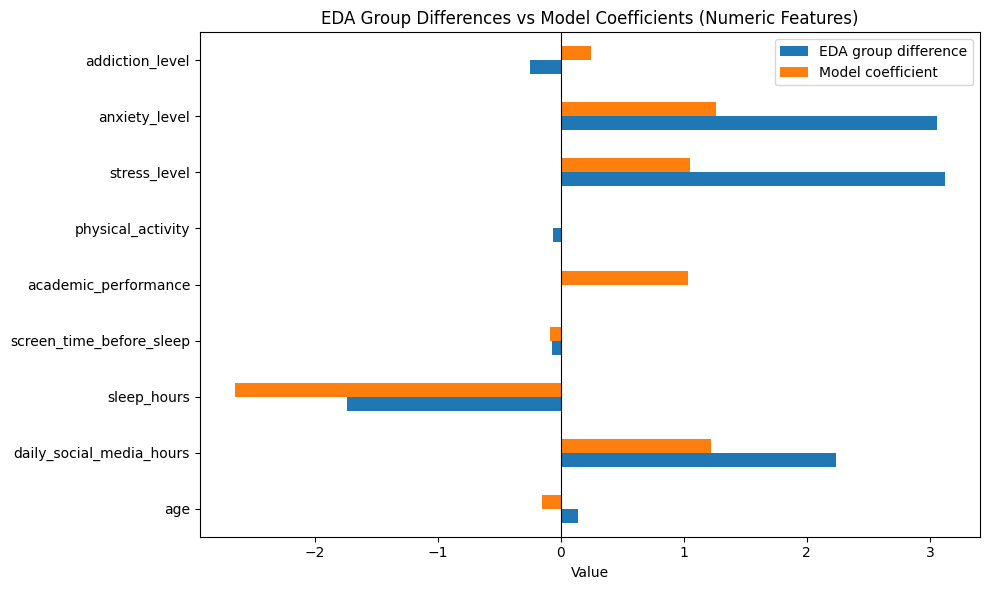

In [221]:
numeric_features = ['age', 'daily_social_media_hours', 'sleep_hours',
                    'screen_time_before_sleep', 'academic_performance',
                    'physical_activity', 'stress_level',
                    'anxiety_level', 'addiction_level']

group_means = df.groupby('depression_label')[numeric_features].mean()
group_diff = group_means.loc[1] - group_means.loc[0]

coef_series = pd.Series(model_balanced.coef_[0], index=X_train.columns)
coef_numeric = coef_series[numeric_features]

comparison_df = pd.DataFrame({
    'EDA group difference': group_diff,
    'Model coefficient': coef_numeric
})

comparison_df.plot(kind='barh', figsize=(10, 6))
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('EDA Group Differences vs Model Coefficients (Numeric Features)')
plt.xlabel('Value')
plt.tight_layout()
plt.show()

## 10. Conclusion

Across this analysis, four behavioral variables emerged as reliable predictors of depression in this dataset: lower sleep hours, higher daily social media use, higher stress, and higher anxiety. These findings were established first through group comparison (depressed vs non-depressed users), then independently confirmed by the trained model's largest coefficients.

The final model — logistic regression with class weighting and a tuned decision threshold of 0.4 — caught all 6 depressed users in the held-out test set, at the cost of 6 false positives among 234 non-depressed users (100% recall, 50% precision). For a depression screening use case, this trade-off favors recall over precision, which matches the cost structure: missing a depressed case is more harmful than producing a false alarm that gets resolved through follow-up.

The Random Forest model, despite being more flexible, underperformed the logistic regression. This is a useful reminder that model complexity should match data size: with only 25 depressed examples in training, a simpler model captures the available signal more reliably than a more powerful one prone to overfitting.

Finally, the project illustrates the importance of cross-checking model output against independent evidence. The model assigned large coefficients to several features (gender, platform usage, academic performance) where the underlying group differences in the data were minimal or absent. Without the EDA work as a validation framework, these spurious coefficients could have been reported as findings. This is a standard pitfall on small or imbalanced data, and the appropriate response is humility about what the model has and hasn't learned.